# Exploratory Data Analysis on Synthetic Data

## Objective

The purpose of this analysis is to evaluate the structure, quality, and realism of a synthetically generated survey dataset before applying natural language processing and machine-learning techniques.

The synthetic dataset serves as a privacy-preserving proxy for real-world employee survey data and enables the development, testing, and validation of analytical workflows without exposing sensitive information.

The exploratory analysis focuses on:

- data quality and completeness,
- consistency of generated survey responses,
- distribution of survey scales and derived features,
- variation across simulated organisational units,
- free-text comment characteristics,
- and suitability for downstream NLP and machine-learning tasks.

Particular attention is given to whether the synthetic data reproduces realistic patterns observed in employee feedback, including response distributions, relationships between survey dimensions, and commenting behaviour.

All findings presented in this notebook are exploratory and intended to support subsequent feature engineering, model selection, pipeline development, dashboard design, and result interpretation.

The goal is not to validate business insights, but to verify that the synthetic dataset provides a sufficiently realistic foundation for developing and evaluating the ELFI (Emotional & Latent Feedback Interpretation) framework.

---

# 1. Data Import & Initial Inspection

---

This section provides a first overview of the dataset.

The goals are to:

- load the transformed survey data,
- inspect its structure and dimensions,
- review variable types,
- identify missing values,
- and detect obvious data-quality issues before cleaning and feature engineering.

## Imports & Configuration

This section imports the required libraries and applies a consistent notebook configuration.

The configuration aims to:

- ensure reproducibility,
- improve readability of tables and plots,
- and provide a consistent visual style throughout the analysis.

In [22]:
# ============================================================
# Imports & Configuration
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
from IPython.display import display

# General notebook configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plotting style
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Reproducibility
RANDOM_STATE = 42

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")


## 1.1 Load Data

This section loads the prepared High5 dataset that serves as the basis for all subsequent analyses.

The imported dataset contains:

- survey responses from multiple High5 iterations,
- Likert-scale items,
- organisational metadata,
- free-text comments,
- and additional variables required for data-quality checks and feature engineering.

At this stage, no transformations are applied. The objective is simply to load the data and confirm that the import was successful before proceeding with cleaning and exploratory analysis.

The following checks will be performed:

- dataset dimensions,
- column names,
- data types,
- and a first inspection of the imported records.

In [23]:
# ============================================================
# Load Data
# ============================================================

# Read the transformed High5 dataset.
# The original raw export has already been standardised and merged across
# survey iterations during the preprocessing step.
df_raw = pd.read_csv(
    '../data/synthetic/synthetic_employee_survey_5000.csv'
)

# Keep the raw dataset unchanged as a reference.
# All cleaning and transformation steps below modify `data` in place.
# Creating a working copy ensures that the original import remains available
# throughout the analysis.
data = df_raw.copy()

# Confirm that the dataset was loaded successfully.
n_rows, n_columns = data.shape

print(f'Rows: {n_rows:,}')
print(f'Columns: {n_columns:,}')

# Preview the first records.
display(data.head())

# Inspect the overall dataset structure.
# This includes variable types, non-missing counts and memory usage.
data.info()

Rows: 7,000
Columns: 66


,ID,Startzeit,Fertigstellungszeit,E-Mail,Name,Language,Ich arbeite bei ...,[Organization]: Ich arbeite im Bereich ...,team_effizienz,staerken_nutzen,zusammenarbeit_team,psychologische_sicherheit,info_fuehrung_veraenderung,produktgestaltung_aktiv,weiterentwicklung_foerderung,fehlerkultur_keine_vorwuerfe,gestaltungsspielraum,kundenfokus,businessentscheidungen_richtung,ehrlichkeit_fuehrung,anforderung_faehigkeit_match,feedback_nutzen,eigenverantwortung_entscheidungen,neues_lernen,beitrag_kundennutzen,erwartungsklarheit,einbeziehung_fuehrung,anspruchsvolle_aufgaben,fehlerkultur_massnahmen,veraenderung_nachvollziehbar,prozessverbesserung_kontinuierlich,einfluss_arbeitsmenge,strategie_einfluss,entscheidungsgeschwindigkeit,prozesse_hinterfragen,hilfe_bitten,lob_anerkennung,klare_ziele,faehigkeiten_ausbau,meinungsfreiheit,zusammenarbeit_schnittstellen,veraenderung_vorantreiben,externe_impulse,respekt,tools_technologien,kulturentwicklung_richtung,offene_kommunikation,strategieklarheit,neue_ideen_ausprobieren,effizienz_schnittstellen,beitrag_wettbewerbsfaehigkeit,arbeitsinformationen,info_geschaeftslage,veraenderung_aktiv,zielbeitrag_strategie,verantwortung_foerderung,rahmenbedingungen_change,arbeitgeber_empfehlung,arbeitsfreude,teamstimmung,work_life_balance,ueberlastung,freitext_kommentar,IterationID,RunID,AbteilungsID
0,NaN,2024-10-10 12:37:00,2024-10-10 12:46:00,user_0@example.org,NaN,de,Zukunfts-Hub 02,FO-GA (Fokusbereich Gamma),Stimme eher zu,Stimme eher nicht zu,Stimme eher nicht zu,Teils/teils,Teils/teils,Stimme eher nicht zu,Stimme eher zu,Stimme eher zu,Teils/teils,Teils/teils,Stimme voll zu,Stimme eher nicht zu,Teils/teils,Stimme eher nicht zu,Teils/teils,Teils/teils,Stimme eher zu,Stimme eher nicht zu,Teils/teils,Stimme voll zu,Teils/teils,Stimme eher zu,Teils/teils,Stimme eher zu,Stimme eher zu,Teils/teils,Teils/teils,Stimme eher nicht zu,Stimme eher nicht zu,Teils/teils,Stimme eher zu,Stimme eher zu,Stimme eher nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Teils/teils,Stimme voll zu,Stimme eher zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme eher zu,Stimme eher zu,Stimme eher nicht zu,Stimme eher nicht zu,Teils/teils,Stimme eher nicht zu,Stimme eher zu,Stimme eher zu,Stimme eher nicht zu,Teils/teils,Teils/teils,Stimme eher zu,Teils/teils,Im Kontext 'Wissensaustausch und Lernen' werde...,#21,1.0,865.0
1,NaN,2024-05-20 19:11:00,2024-05-20 19:27:00,user_1@example.org,NaN,de,Inkubator-Einheit 04,KE-EP (Kernbereich Epsilon),Stimme eher nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Teils/teils,Stimme eher nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme gar nicht zu,Stimme eher nicht zu,Teils/teils,Stimme gar nicht zu,Stimme voll zu,NaN,#11,1.0,254.0
2,NaN,2024-04-10 13:14:00,2024-04-10 13:30:00,user_2@example.org,NaN,de,Spezialisten-Kreis 06,ZU-BE (Zukunftssegment Beta),Stimme voll zu,Teils/teils,Stimme voll zu,Stimme voll zu,Stimme voll zu,Stimme eher zu,Stimme eher zu,Stimme eher zu,Stimme eher nicht zu,Teils/teils,Stimme eher zu,Stimme eher zu,Teils/teils,Teils/teils,Stimme eher zu,Teils/teils,Stimme voll zu,Stimme voll zu,Stimme eher zu,Stimme eher 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 66 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   ID                                          0 non-null      float64
 1   Startzeit                                   7000 non-null   object 
 2   Fertigstellungszeit                         7000 non-null   object 
 3   E-Mail                                      7000 non-null   object 
 4   Name                                        0 non-null      float64
 5   Language                                    7000 non-null   object 
 6   Ich arbeite bei ...                         7000 non-null   object 
 7   [Organization]: Ich arbeite im Bereich ...  7000 non-null   object 
 8   team_effizienz                              7000 non-null   object 
 9   staerken_nutzen                             7000 non-null   object 
 10  zusammenarbe

## 1.2 Dataset Overview

This section provides a high-level overview of the dataset structure before any cleaning or transformation steps are applied.

The objective is to understand:

- the overall size of the dataset,
- the available variables,
- data types and storage formats,
- the prevalence of missing values,
- and the general composition of the survey responses.

This initial inspection helps identify potential data-quality issues and informs the subsequent cleaning and feature-engineering steps.

Special attention is paid to:

- survey metadata,
- organisational variables,
- Likert-scale items,
- free-text fields,
- and variables required for data-quality assessment.

The findings from this section provide the foundation for all later analyses and modelling decisions.

In [24]:
# ============================================================
# Dataset Dimensions & Variables
# ============================================================

# Display the overall dimensions of the dataset.
# This provides a first impression of the number of survey responses
# and available variables.
n_rows, n_columns = data.shape

print(f"Dataset shape: {n_rows:,} rows × {n_columns:,} columns")

# Display all column names.
# This helps identify survey metadata, organisational variables,
# Likert items and free-text fields.
print("\nColumns:")
display(pd.DataFrame({"column_name": data.columns}))

# Summarise variable types.
# A high number of object columns is expected at this stage because
# Likert responses are still stored as text.
dtype_summary = (
    data.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="count")
)

print("\nVariable types:")
display(dtype_summary)

# Count missing values for each variable.
# This overview helps identify variables that require special attention
# during the cleaning and missingness analysis.
missing_summary = (
    data.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_values")
    .to_frame()
)

missing_summary["share_%"] = (
    missing_summary["missing_values"]
    / len(data)
    * 100
).round(1)

print("\nVariables with the highest number of missing values:")
display(missing_summary.head(20))

Dataset shape: 7,000 rows × 66 columns

Columns:


,column_name
0,ID
1,Startzeit
2,Fertigstellungszeit
3,E-Mail
4,Name
5,Language
6,Ich arbeite bei ...
7,[Organization]: Ich arbeite im Bereich ...
8,team_effizienz
9,staerken_nutzen



Variable types:


,dtype,count
0,object,62
1,float64,4



Variables with the highest number of missing values:


,missing_values,share_%
ID,7000,100.0
Name,7000,100.0
freitext_kommentar,2000,28.6
externe_impulse,0,0.0
strategieklarheit,0,0.0
offene_kommunikation,0,0.0
kulturentwicklung_richtung,0,0.0
tools_technologien,0,0.0
respekt,0,0.0
zusammenarbeit_schnittstellen,0,0.0


---

# 2. Data Cleaning

---

Before analysing the survey responses, several data-cleaning steps are performed to ensure data quality and consistency.

The objectives of this stage are to:

- identify and remove malformed records,
- standardise timestamp variables,
- clean organisational variables,
- and prepare the dataset for subsequent analyses.

All cleaning decisions are documented explicitly to ensure transparency and reproducibility. The original imported dataset (`df_raw`) remains unchanged and serves as a reference throughout the analysis.

Unless stated otherwise, cleaned variables are created or updated in the working dataset (`data`), which is used for all subsequent exploratory analyses.

## 2.1 Remove Malformed Records

A small number of records contain invalid response values that do not belong to the expected Likert response categories.

These records most likely originate from import, transformation, or export issues and would interfere with the subsequent recoding of survey items.

Before continuing with the analysis, malformed records are identified, inspected, and removed from the working dataset.

The removal is applied only to clearly invalid cases and is documented explicitly to ensure transparency and reproducibility.

In [25]:
# ============================================================
# Identify and Remove Malformed Records
# ============================================================

# Inspect unique values in the workload item.
# During the initial data inspection, a small number of unexpected values
# were identified that do not belong to the defined Likert scale.
display(
    data["ueberlastung"]
    .value_counts(dropna=False)
)

# Identify records containing malformed values.
# These values are not valid survey responses and likely stem from
# transformation or export issues.
malformed_mask = (
    data["ueberlastung"]
    .astype("string")
    .isin(["90", "238"])
)

print(f"Malformed records identified: {malformed_mask.sum()}")

# Display the affected records before removal.
display(
    data.loc[
        malformed_mask
    ]
)

# Remove malformed records from the working dataset.
data = data.loc[
    ~malformed_mask
].copy()

# Verify the result.
print(f"Rows after cleaning: {len(data):,}")

display(
    data["ueberlastung"]
    .value_counts(dropna=False)
)

ueberlastung
Stimme eher nicht zu    2068
Teils/teils             1981
Stimme eher zu          1454
Stimme gar nicht zu      787
Stimme voll zu           710
Name: count, dtype: int64

Malformed records identified: 0


,ID,Startzeit,Fertigstellungszeit,E-Mail,Name,Language,Ich arbeite bei ...,[Organization]: Ich arbeite im Bereich ...,team_effizienz,staerken_nutzen,zusammenarbeit_team,psychologische_sicherheit,info_fuehrung_veraenderung,produktgestaltung_aktiv,weiterentwicklung_foerderung,fehlerkultur_keine_vorwuerfe,gestaltungsspielraum,kundenfokus,businessentscheidungen_richtung,ehrlichkeit_fuehrung,anforderung_faehigkeit_match,feedback_nutzen,eigenverantwortung_entscheidungen,neues_lernen,beitrag_kundennutzen,erwartungsklarheit,einbeziehung_fuehrung,anspruchsvolle_aufgaben,fehlerkultur_massnahmen,veraenderung_nachvollziehbar,prozessverbesserung_kontinuierlich,einfluss_arbeitsmenge,strategie_einfluss,entscheidungsgeschwindigkeit,prozesse_hinterfragen,hilfe_bitten,lob_anerkennung,klare_ziele,faehigkeiten_ausbau,meinungsfreiheit,zusammenarbeit_schnittstellen,veraenderung_vorantreiben,externe_impulse,respekt,tools_technologien,kulturentwicklung_richtung,offene_kommunikation,strategieklarheit,neue_ideen_ausprobieren,effizienz_schnittstellen,beitrag_wettbewerbsfaehigkeit,arbeitsinformationen,info_geschaeftslage,veraenderung_aktiv,zielbeitrag_strategie,verantwortung_foerderung,rahmenbedingungen_change,arbeitgeber_empfehlung,arbeitsfreude,teamstimmung,work_life_balance,ueberlastung,freitext_kommentar,IterationID,RunID,AbteilungsID


Rows after cleaning: 7,000


ueberlastung
Stimme eher nicht zu    2068
Teils/teils             1981
Stimme eher zu          1454
Stimme gar nicht zu      787
Stimme voll zu           710
Name: count, dtype: int64

## 2.2 Remove Unused Variables

The survey export contains several variables that are not required for the subsequent analyses.

Before proceeding with data preparation, variables are reviewed and removed where appropriate.

Particular attention is paid to the language variable because this project focuses on German-language survey responses. The presence of multiple languages would require substantially different text-processing and modelling strategies.

Several technical export fields are removed, while identifiers required for traceability and survey-wave analyses are retained.

In [26]:
# ============================================================
# Remove Unused Variables
# ============================================================

# Check language distribution before removing the variable.
# A multilingual dataset would require different preprocessing and NLP steps.
print("Language distribution:")
display(
    data["Language"]
    .value_counts(dropna=False)
)

# Remove variables that do not add analytical value.
# Keep survey identifiers because they are useful for traceability,
# survey-wave analyses and result mapping.
data = data.drop(
    columns=[
        "E-Mail",
        "Name",
        "Language"
    ]
)

# Verify remaining dimensions.
print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape,}")

Language distribution:


Language
de    6652
en     348
Name: count, dtype: int64

Rows: 7,000
Columns: ((7000, 63),)


## 2.3 Standardise Column Names

The original survey export contains column names with inconsistent spacing, invisible characters, and German-language labels.

To improve readability and simplify downstream analyses, column names are cleaned and selected variables are renamed using a consistent snake_case naming convention.

This standardisation reduces the risk of coding errors and makes subsequent feature engineering steps easier to maintain.

In [27]:
# ============================================================
# Standardise Column Names
# ============================================================

# Remove invisible characters and standardise whitespace.
data.columns = (
    data.columns
    .str.replace(r"\u200b", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Rename frequently used variables.
column_mapping = {
    "ID": "id",
    "Startzeit": "start",
    "Fertigstellungszeit": "ende",
    "Ich arbeite bei ...": "organisation",
    "[Organization]: Ich arbeite im Bereich ...": "bereich",
    "IterationID": "iteration_id",
    "RunID": "run_id",
    "AbteilungsID": "abteilungs_id"
}

data = data.rename(columns=column_mapping)

print("Column names standardised.")

display(
    pd.DataFrame({
        "column_name": data.columns
    }).head(20)
)

Column names standardised.


,column_name
0,id
1,start
2,ende
3,organisation
4,bereich
5,team_effizienz
6,staerken_nutzen
7,zusammenarbeit_team
8,psychologische_sicherheit
9,info_fuehrung_veraenderung


## 2.4 Convert Time Variables

The survey export contains start and completion timestamps that are initially stored in Excel date format.

To support subsequent data-quality analyses, the timestamps are converted to datetime values and used to calculate the completion time for each response.

The resulting completion-time variable serves as a descriptive measure of respondent behaviour and is later used to identify potentially implausible response patterns, such as unusually short completion times.

In [28]:
# ============================================================
# Convert Time Variables
# ============================================================

# Convert timestamp columns to pandas datetime format.
# The transformed dataset already stores timestamps as date-time strings.

data["start"] = pd.to_datetime(
    data["start"],
    errors="coerce"
)

data["ende"] = pd.to_datetime(
    data["ende"],
    errors="coerce"
)

# Calculate survey completion time in minutes.
data["duration_minutes"] = (
    data["ende"]
    .sub(data["start"])
    .dt.total_seconds()
    .div(60)
)

# Negative durations are invalid and converted to missing values.
data.loc[
    data["duration_minutes"] < 0,
    "duration_minutes"
] = np.nan

# Display a quick overview of completion times.
display(
    data["duration_minutes"]
    .describe()
    .round(2)
)

count    7000.00
mean       13.88
std         6.63
min         3.00
25%         8.00
50%        14.00
75%        20.00
max        25.00
Name: duration_minutes, dtype: float64

## 2.5 Clean Organisational Variables

The organisational variables contain labels from multiple hierarchy levels, including divisions, business units, sub-units, and teams.

Before analysing organisational differences, these labels are cleaned and standardised to improve consistency across survey iterations.

Three organisational variables are retained:

- **`bereich`**: original organisational label from the survey export,
- **`bereich_clean`**: cleaned organisational label with obvious placeholders and malformed values removed,
- **`bereich_ebene`**: aggregated business-unit level (e.g. `RM-HW`, `RM-FS`, `SE-CS`, `IT-MP`) derived from the original hierarchy.

The business-unit level is used throughout the subsequent analyses because it reduces sparsity, increases group sizes, and allows more meaningful comparisons between organisational units.

The original labels remain available to preserve traceability and support later drill-down analyses.

In [29]:
# ============================================================
# Clean Organisational Variables
# ============================================================

# Create a cleaned version of the organisational variable.
# The original variable is retained to preserve traceability.

data["bereich_clean"] = (
    data["bereich"]
    .astype("string")
    .str.strip()
)

# Replace obvious placeholders and invalid labels with missing values.
invalid_bereich_values = {
    "",
    ".",
    "..",
    "...",
    "/",
    '" / "',
    '"/"',
    "xxx",
    "XXX",
    "n/a",
    "N/A",
    "na",
    "NA",
    "nan",
    "None"
}

data["bereich_clean"] = data["bereich_clean"].replace(
    invalid_bereich_values,
    pd.NA
)

# Remove extremely short labels that are unlikely to represent
# meaningful organisational units.
data.loc[
    data["bereich_clean"].str.len().fillna(0) < 3,
    "bereich_clean"
] = pd.NA

print(
    f"Original number of business unit labels: "
    f"{data['bereich'].nunique(dropna=True)}"
)

print(
    f"Cleaned number of business unit labels: "
    f"{data['bereich_clean'].nunique(dropna=True)}"
)

print(
    f"Missing cleaned business units: "
    f"{data['bereich_clean'].isna().sum()}"
)

# ------------------------------------------------------------
# Create business-unit level variable
# ------------------------------------------------------------

# The original organisational variable contains mixed hierarchy levels.
# This helper extracts the business-unit level (e.g. RM-HW, RM-FS,
# SE-CS, IT-MP) to obtain more stable group sizes for analysis.

def extract_bereichsebene(text):

    if pd.isna(text):
        return pd.NA

    code = str(text).split(" ")[0]

    parts = code.split("-")

    if len(parts) >= 2:
        return "-".join(parts[:2])

    return code


data["bereich_ebene"] = (
    data["bereich_clean"]
    .apply(extract_bereichsebene)
)

print(
    f"\nUnique organisational labels: "
    f"{data['bereich_clean'].nunique(dropna=True)}"
)

print(
    f"Unique business-unit labels: "
    f"{data['bereich_ebene'].nunique(dropna=True)}"
)

# Review the mapping from detailed labels to business-unit level.
display(
    data[
        ["bereich_clean", "bereich_ebene"]
    ]
    .drop_duplicates()
    .sort_values("bereich_ebene")
    .head(30)
)

# ------------------------------------------------------------
# Inspect business-unit sizes
# ------------------------------------------------------------

bereich_sizes = (
    data["bereich_ebene"]
    .value_counts()
    .rename_axis("bereich_ebene")
    .reset_index(name="n")
)

display(bereich_sizes.head(20))

display(
    bereich_sizes["n"]
    .describe()
    .round(2)
)

print(
    f"Business units with fewer than 5 responses: "
    f"{(bereich_sizes['n'] < 5).sum()}"
)

print(
    f"Business units with fewer than 30 responses: "
    f"{(bereich_sizes['n'] < 30).sum()}"
)

Original number of business unit labels: 5
Cleaned number of business unit labels: 5
Missing cleaned business units: 0

Unique organisational labels: 5
Unique business-unit labels: 5


,bereich_clean,bereich_ebene
0,FO-GA (Fokusbereich Gamma),FO-GA
6,IN-AL (Innovationsfeld Alpha),IN-AL
1,KE-EP (Kernbereich Epsilon),KE-EP
5,TR-DE (Transformationsfeld Delta),TR-DE
2,ZU-BE (Zukunftssegment Beta),ZU-BE


,bereich_ebene,n
0,ZU-BE,1426
1,FO-GA,1412
2,KE-EP,1402
3,TR-DE,1380
4,IN-AL,1380


count       5.00
mean     1400.00
std        20.15
min      1380.00
25%      1380.00
50%      1402.00
75%      1412.00
max      1426.00
Name: n, dtype: float64

Business units with fewer than 5 responses: 0
Business units with fewer than 30 responses: 0


## 2.6 Remove Empty Variables & Create Analysis Helpers

The transformed dataset contains a small number of variables that are present in the schema but do not contain any valid observations.

These variables cannot contribute to descriptive analyses, score calculations, reliability assessments, or machine-learning models and are therefore removed from the working dataset.

In addition, several helper variables are created that are used throughout the subsequent analyses. In particular, a binary indicator is generated to distinguish respondents who provided a free-text comment from those who did not.

These helper variables do not modify the original survey content but facilitate later organisational and free-text analyses.

In [30]:
# ============================================================
# Remove Empty Variables
# ============================================================

# Identify variables that contain only missing values.
empty_columns = [
    col
    for col in data.columns
    if data[col].notna().sum() == 0
]

print(f"Empty variables detected: {len(empty_columns)}")

if empty_columns:
    display(
        pd.DataFrame({
            "variable": empty_columns
        })
    )

# Remove empty variables from the working dataset.
data = data.drop(
    columns=empty_columns,
    errors="ignore"
)

print(
    f"Remaining variables: {data.shape[1]}"
)

# ============================================================
# Free-Text Participation Indicator
# ============================================================

# Create a binary indicator showing whether a respondent
# provided a free-text comment.

data["has_comment"] = (
    data["freitext_kommentar"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

print(
    f"Responses with comment: "
    f"{data['has_comment'].sum():,}"
)

print(
    f"Responses without comment: "
    f"{(~data['has_comment']).sum():,}"
)

print(
    f"Comment rate: "
    f"{data['has_comment'].mean() * 100:.1f}%"
)

Empty variables detected: 1


,variable
0,id


Remaining variables: 65
Responses with comment: 5,000
Responses without comment: 2,000
Comment rate: 71.4%


---

# 3. Survey Structure & Missingness

---

Before recoding and analysing the survey responses, the questionnaire structure and missing-value patterns are examined.

The High5 dataset combines multiple survey iterations and questionnaire versions. As a result, missing values can originate from different sources, including:

- respondents skipping individual questions,
- respondents selecting non-substantive response options,
- and structural differences between survey versions.

Understanding these missingness patterns is essential because they directly influence feature engineering, psychometric analyses, correlation structures, and downstream machine-learning models.

This section therefore focuses on:

- identifying valid Likert items,
- standardising response categories,
- distinguishing between different types of missing values,
- and investigating structural missingness across questionnaire versions.

## 3.1 Likert Response Preparation

The survey items are stored as text labels rather than numeric values.

Before recoding, response categories are standardised to ensure that identical answers are represented consistently across survey iterations and exports.

This step includes:

- normalisation of whitespace and formatting differences,
- correction of known spelling variants,
- standardisation of non-substantive response categories,
- and preparation for automated Likert-item detection.

The original meaning of all response categories is preserved throughout the process.

In [31]:
# ============================================================
# Likert Response Preparation
# ============================================================

# Valid Likert response categories and their numeric values.
# These values are used later during numeric recoding.

likert_mapping = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Teils/teils": 3,
    "Teils/Teils": 3,
    "Stimme eher zu": 4,
    "Stimme voll zu": 5,
    "Stimme voll und ganz zu": 5
}


# Non-substantive response category.
# This response does not represent a position on the underlying construct
# and is therefore deliberately excluded from the numeric mapping.
NO_JUDGEMENT = "Kann ich nicht beurteilen"

# All valid response labels before numeric recoding.
likert_labels = set(likert_mapping) | {NO_JUDGEMENT}


def normalise_likert(series: pd.Series) -> pd.Series:
    """
    Standardise Likert response texts before item detection and recoding.

    The function:
    - removes line breaks,
    - standardises whitespace,
    - standardises dash variants,
    - fixes known spelling variants,
    - maps alternative non-substantive responses to a common label.
    """

    cleaned = (
        series.astype("string")
        .str.replace(r"[\r\n]+", " ", regex=True)
        .str.replace("–", "-", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    cleaned = cleaned.replace({
        # spelling variant observed in the data
        "Kann ich nciht beurteilen": NO_JUDGEMENT,

        # abbreviated non-substantive responses
        "kA": NO_JUDGEMENT,
        "KA": NO_JUDGEMENT,
        "k.A.": NO_JUDGEMENT,
        "K.A.": NO_JUDGEMENT,
    })

    return cleaned


# Quick validation of the defined response categories.
print("Valid Likert response labels:")
for label in sorted(likert_labels):
    print(f"  • {label}")

Valid Likert response labels:
  • Kann ich nicht beurteilen
  • Stimme eher nicht zu
  • Stimme eher zu
  • Stimme gar nicht zu
  • Stimme voll und ganz zu
  • Stimme voll zu
  • Teils/Teils
  • Teils/teils


## 3.2 Standardise Response Categories

Although the survey primarily uses consistent Likert response categories, several formatting and spelling variants were identified during data inspection.

Examples include:

- inconsistent whitespace,
- line breaks and hidden characters,
- spelling variants of response options,
- abbreviated non-substantive responses such as `kA`,
- and explicit non-judgement responses such as `Kann ich nicht beurteilen`.

Before numerical recoding, all response labels are standardised to ensure that semantically identical answers are represented consistently.

Particular attention is paid to non-substantive responses. These responses do not represent a position on the underlying construct and are therefore handled separately from valid Likert responses.

The standardisation process allows a clear distinction between:

- valid Likert responses,
- explicit non-judgement responses,
- and genuine missing values caused by item non-response.

In [32]:
# ============================================================
# Standardise Response Categories
# ============================================================

# Apply the response normalisation function to all object variables.
# This creates a temporary standardised representation that is used
# for item detection and subsequent quality checks.

object_columns = data.select_dtypes(include="object").columns

standardised_text = data[object_columns].apply(normalise_likert)

# Inspect the most common non-substantive response category.
non_judgement_count = (
    standardised_text
    .eq(NO_JUDGEMENT)
    .sum()
    .sum()
)

print(
    f'"{NO_JUDGEMENT}" responses detected: '
    f'{non_judgement_count:,}'
)

# Quick validation:
# Check whether unknown response categories remain after standardisation.
unknown_values = set()

for col in object_columns:

    values_found = set(
        standardised_text[col]
        .dropna()
        .unique()
    )

    unknown_values.update(
        values_found - likert_labels
    )

print("\nUnknown response labels after standardisation:")
print(sorted(unknown_values))

"Kann ich nicht beurteilen" responses detected: 0

Unknown response labels after standardisation:
['#01', '#02', '#03', '#04', '#05', '#06', '#07', '#08', '#09', '#10', '#11', '#12', '#13', '#14', '#15', '#16', '#17', '#18', '#19', '#20', '#21', '#22', '#23', '#24', '#25', '#26', '#27', '#28', '#29', '#30', 'FO-GA', 'FO-GA (Fokusbereich Gamma)', 'Fokus-Zelle 03', 'IN-AL', 'IN-AL (Innovationsfeld Alpha)', "Im Kontext 'Kein spezifischer Fokus' werden insbesondere Themen rund um Arbeitgeberattraktivität diskutiert. Entwicklungsmöglichkeiten beeinflussen die Attraktivität des Arbeitgebers. An Schnittstellen entstehen weiterhin Abstimmungsbedarfe. Die Wahrnehmung bleibt überwiegend sachlich und abwägend. Nicht alle Auswirkungen lassen sich derzeit eindeutig bewerten. Eine regelmäßige Überprüfung der Ergebnisse wird empfohlen. Insgesamt zeigt sich innerhalb von TR-DE (Transformationsfeld Delta) ein differenziertes Bild, bei dem Chancen und Herausforderungen gleichzeitig sichtbar werden.", "I

## 3.3 Detect Likert Items

The High5 dataset contains a mixture of survey items, metadata, organisational variables, identifiers, and free-text fields.

Rather than relying on predefined column positions, Likert items are identified automatically based on their observed response categories.

A variable is classified as a Likert item if all non-missing values belong to the predefined set of valid response options.

This approach is robust to:

- changes in questionnaire structure,
- different survey iterations,
- varying column orders,
- and future extensions of the dataset.

The resulting list of detected Likert items forms the foundation for all subsequent recoding, psychometric analyses, and feature-engineering steps.

In [33]:
# ============================================================
# Detect Likert Items
# ============================================================

# Identify Likert items based on their observed response values.
# Using response categories instead of column positions makes the
# detection robust across survey iterations and questionnaire versions.

cols_to_recode = []

for col in data.select_dtypes(include="object").columns:

    values_found = set(
        normalise_likert(data[col])
        .dropna()
        .unique()
    )

    if values_found and values_found <= likert_labels:
        cols_to_recode.append(col)

print(f"Detected Likert items: {len(cols_to_recode)}")

# ------------------------------------------------------------
# Review variables that were not classified as Likert items
# ------------------------------------------------------------

not_detected = [
    col
    for col in data.select_dtypes(include="object").columns
    if col not in cols_to_recode
]

print("\nVariables not detected as Likert items:")
display(
    pd.DataFrame(
        {"variable": not_detected}
    )
)

# ------------------------------------------------------------
# Summarise detected Likert items
# ------------------------------------------------------------

likert_item_summary = pd.DataFrame({
    "valid_responses": data[cols_to_recode].notna().sum()
}).sort_values(
    "valid_responses",
    ascending=False
)

print("\nDetected Likert items:")
display(
    likert_item_summary
)

Detected Likert items: 54

Variables not detected as Likert items:


,variable
0,organisation
1,bereich
2,freitext_kommentar
3,iteration_id
4,bereich_ebene



Detected Likert items:


,valid_responses
team_effizienz,7000
neue_ideen_ausprobieren,7000
klare_ziele,7000
faehigkeiten_ausbau,7000
meinungsfreiheit,7000
zusammenarbeit_schnittstellen,7000
veraenderung_vorantreiben,7000
externe_impulse,7000
respekt,7000
tools_technologien,7000


## 3.4 Cannot Judge vs Missing Values

Missing values in survey data can originate from different sources and should not automatically be treated as equivalent.

In the High5 questionnaire, two distinct situations can lead to missing values in the analytical dataset:

1. **Explicit non-judgement responses**
   - Respondents actively selected *"Kann ich nicht beurteilen"*.
   - These responses indicate that participants chose not to evaluate the item.
   - They do not represent missing data in the traditional sense.

2. **Item non-response**
   - Respondents did not provide an answer.
   - These values are recorded as genuine missing values.

Distinguishing between these two cases is important because they reflect different respondent behaviours and may have different implications for subsequent analyses and machine-learning models.

Before numerical recoding, both types of responses are therefore documented separately.

In [34]:
# ============================================================
# Cannot Judge vs Missing Values
# ============================================================

# Standardise Likert response texts once and reuse the result throughout
# the subsequent recoding and quality-checking steps.
likert_text = data[cols_to_recode].apply(normalise_likert)

# Two distinct sources of missing values:
#
# - Explicit non-judgement responses:
#   respondents selected "Kann ich nicht beurteilen".
#
# - Item non-response:
#   respondents skipped the question.

no_judgement_mask = (
    (likert_text == NO_JUDGEMENT)
    .fillna(False)
    .astype(bool)
)

skipped_mask = likert_text.isna()

# Summarise both forms of non-substantive responses per item.
answer_quality = pd.DataFrame({
    "no_judgement": no_judgement_mask.sum(),
    "share_%": (
        no_judgement_mask.mean() * 100
    ).round(1),
    "skipped": skipped_mask.sum(),
}).sort_values(
    "no_judgement",
    ascending=False
)

print(
    f'"{NO_JUDGEMENT}": '
    f'{no_judgement_mask.values.sum():,} responses '
    f'({no_judgement_mask.values.mean() * 100:.1f}%)'
)

print(
    f"Skipped questions: "
    f"{skipped_mask.values.sum():,}"
)

print("\nItems respondents were least able to judge:")

display(
    answer_quality.head(10)
)

"Kann ich nicht beurteilen": 0 responses (0.0%)
Skipped questions: 0

Items respondents were least able to judge:


,no_judgement,share_%,skipped
team_effizienz,0,0.0,0
neue_ideen_ausprobieren,0,0.0,0
klare_ziele,0,0.0,0
faehigkeiten_ausbau,0,0.0,0
meinungsfreiheit,0,0.0,0
zusammenarbeit_schnittstellen,0,0.0,0
veraenderung_vorantreiben,0,0.0,0
externe_impulse,0,0.0,0
respekt,0,0.0,0
tools_technologien,0,0.0,0


---

# 4. Survey Score Preparation

---

The questionnaire responses are transformed into analysis-ready survey scores.

The purpose of this stage is to prepare the survey data for descriptive analyses while preserving the meaning of the original responses.

The following steps are performed:

- conversion of Likert response categories into numeric values,
- preservation of information about non-substantive responses,
- application of reverse coding where required,
- construction of theoretically meaningful topic groups,
- calculation of aggregate topic scores.

The resulting survey scores form the basis for the remaining exploratory analyses, including reliability assessment, organisational comparisons, and free-text investigations.

Although these transformations prepare the data for later modelling workflows, the primary objective at this stage is exploratory analysis rather than machine-learning feature engineering.

## 4.1 Numeric Recoding

To enable quantitative analyses, the standardised Likert response categories are converted into numeric values.

The predefined response scale is mapped as follows:

| Response Category | Value |
|-------------------|------:|
| Stimme gar nicht zu | 1 |
| Stimme eher nicht zu | 2 |
| Teils/Teils | 3 |
| Stimme eher zu | 4 |
| Stimme voll und ganz zu | 5 |

Explicit non-judgement responses (*"Kann ich nicht beurteilen"*) are deliberately excluded from the numeric scale because they do not represent a substantive evaluation of the item.

After recoding, both non-judgement responses and genuine item non-response are represented as missing values (`NaN`). However, their original causes remain traceable through the masks created in the previous section.

In [35]:
# ============================================================
# Numeric Recoding
# ============================================================

# Convert standardised Likert responses into numeric values.
# Non-substantive responses ("Cannot judge") are intentionally not included
# in the mapping and therefore become missing values.

data[cols_to_recode] = (
    likert_text
    .apply(lambda s: s.map(likert_mapping))
    .astype("float64")
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

# Every missing value after recoding must originate from either:
# - an explicit non-judgement response, or
# - a skipped question.

assert data[cols_to_recode].isna().equals(
    no_judgement_mask | skipped_mask
), (
    "Unexpected missing values detected after recoding. "
    "At least one response category is not covered by the mapping."
)

print("✓ Numeric recoding completed successfully.")
print("✓ All missing values are explained.")

# Review the resulting response distribution.
display(
    data[cols_to_recode]
    .stack()
    .value_counts()
    .sort_index()
    .rename_axis("response_value")
    .to_frame("count")
)

✓ Numeric recoding completed successfully.
✓ All missing values are explained.


,count
response_value,
1.0,42186
2.0,67618
3.0,97916
4.0,96656
5.0,73624


## 4.2 Reverse Coding

Most survey items are formulated such that higher values indicate more positive evaluations. However, some items represent undesirable states and therefore have an inverse interpretation.

For these items, agreement indicates a less favourable outcome. To ensure that all topic scores are interpreted consistently, negatively worded items are reverse coded.

After reverse coding:

- higher values always represent more favourable conditions,
- topic scores can be compared directly,
- and interpretation becomes more intuitive across analyses.

In the current dataset, the workload item (*"ueberlastung"*) is reverse coded so that higher values indicate lower perceived overload and therefore a more positive situation.

In [36]:
print(data["ueberlastung"].dtype)

display(
    data["ueberlastung"].head(10)
)

float64


0    3.0
1    5.0
2    2.0
3    2.0
4    2.0
5    2.0
6    3.0
7    3.0
8    1.0
9    3.0
Name: ueberlastung, dtype: float64

In [37]:
# ============================================================
# Reverse Coding
# ============================================================

# The workload item is negatively worded.
# Higher agreement indicates a less favourable situation (more overload).
# Reverse coding ensures that higher values consistently represent
# more favourable conditions across all topic scores.

data["ueberlastung_r"] = 6 - data["ueberlastung"]

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

# Compare original and reverse-coded distributions.
reverse_coding_check = pd.DataFrame({
    "original": (
        data["ueberlastung"]
        .value_counts(dropna=False)
        .sort_index()
    ),
    "reverse_coded": (
        data["ueberlastung_r"]
        .value_counts(dropna=False)
        .sort_index()
    ),
})

display(reverse_coding_check)

# Display descriptive statistics for both versions.
display(
    pd.DataFrame({
        "ueberlastung": data["ueberlastung"].describe(),
        "ueberlastung_r": data["ueberlastung_r"].describe(),
    }).round(2)
)

print("✓ Reverse coding completed successfully.")

,original,reverse_coded
1.0,787,710
2.0,2068,1454
3.0,1981,1981
4.0,1454,2068
5.0,710,787


,ueberlastung,ueberlastung_r
count,7000.00,7000.00
mean,2.89,3.11
std,1.16,1.16
min,1.00,1.00
25%,2.00,2.00
50%,3.00,3.00
75%,4.00,4.00
max,5.00,5.00


✓ Reverse coding completed successfully.


## 4.3 Topic Groups

To reduce complexity and support interpretation, individual survey items are grouped into broader thematic dimensions.

The topic structure follows the existing High5 framework and is retained throughout the analysis. Maintaining the original grouping ensures comparability with previous High5 evaluations and with the synthetic reference dataset used in the capstone project.

The questionnaire covers the following thematic areas:

- **Teamwork & Collaboration**: collaboration within and across teams, support, and team climate,
- **Psychological Safety & Culture**: openness, trust, respect, and organisational culture,
- **Leadership & Communication**: leadership behaviour, communication, and change management,
- **Strategy & Business**: strategic direction, organisational alignment, and business context,
- **Work Structure & Responsibility**: autonomy, clarity, accountability, and working conditions,
- **Development & Learning**: learning opportunities, capability development, and personal growth,
- **Customer, Product & Process Focus**: customer orientation, innovation, and continuous improvement,
- **Engagement & Wellbeing**: motivation, recognition, recommendation, and employee wellbeing.

In addition to the thematic groups, organisational, survey-wave, and free-text variables are retained separately because they serve different analytical purposes.

Before calculating aggregated scores, the topic structure is validated to ensure that all detected survey items are assigned correctly and that no items are unintentionally omitted from the analysis.

In [38]:
# ============================================================
# Topic Groups
# ============================================================

# The topic structure follows the existing High5 framework and is retained
# throughout the analysis to ensure comparability with previous High5
# evaluations and the synthetic reference dataset.

# ------------------------------------------------------------
# Organisational Variables
# ------------------------------------------------------------

orga = [
    "organisation",
    "bereich",
    "iteration_id",
    "run_id",
    "abteilungs_id"
]

# ------------------------------------------------------------
# Teamwork & Collaboration
# ------------------------------------------------------------

team = [
    "team_effizienz",
    "zusammenarbeit_team",
    "zusammenarbeit_schnittstellen",
    "effizienz_schnittstellen",
    "hilfe_bitten",
    "teamstimmung"
]

# ------------------------------------------------------------
# Psychological Safety & Culture
# ------------------------------------------------------------

kultur = [
    "psychologische_sicherheit",
    "fehlerkultur_keine_vorwuerfe",
    "fehlerkultur_massnahmen",
    "meinungsfreiheit",
    "respekt",
    "kulturentwicklung_richtung",
    'offene_kommunikation'
]

# ------------------------------------------------------------
# Leadership & Communication
# ------------------------------------------------------------

fuehrung = [
    "ehrlichkeit_fuehrung",
    "einbeziehung_fuehrung",
    "veraenderung_vorantreiben",
    "rahmenbedingungen_change",
    'info_fuehrung_veraenderung',
    'veraenderung_nachvollziehbar'
]

# ------------------------------------------------------------
# Strategy & Business
# ------------------------------------------------------------

# Note:
# 'strategie_einfluss' measures strategic relevance rather than satisfaction.
# High agreement is not necessarily positive but indicates that strategy
# influences day-to-day work decisions.

strategie = [
    "businessentscheidungen_richtung",
    "strategie_einfluss",
    "strategieklarheit",
    "zielbeitrag_strategie",
    "info_geschaeftslage",
    "beitrag_wettbewerbsfaehigkeit"
]

# ------------------------------------------------------------
# Work Structure & Responsibility
# ------------------------------------------------------------

arbeitsgestaltung = [
    "gestaltungsspielraum",
    "eigenverantwortung_entscheidungen",
    "entscheidungsgeschwindigkeit",
    "erwartungsklarheit",
    "klare_ziele",
    "verantwortung_foerderung",
    "einfluss_arbeitsmenge",
    "arbeitsinformationen"
]

# ------------------------------------------------------------
# Development & Learning
# ------------------------------------------------------------

entwicklung = [
    "staerken_nutzen",
    "weiterentwicklung_foerderung",
    "anforderung_faehigkeit_match",
    "feedback_nutzen",
    "neues_lernen",
    "anspruchsvolle_aufgaben",
    "faehigkeiten_ausbau"
]

# ------------------------------------------------------------
# Customer, Product & Process Focus
# ------------------------------------------------------------

wertschoepfung = [
    "produktgestaltung_aktiv",
    "kundenfokus",
    "beitrag_kundennutzen",
    "prozessverbesserung_kontinuierlich",
    "prozesse_hinterfragen",
    "externe_impulse",
    "tools_technologien",
    "neue_ideen_ausprobieren",
    "veraenderung_aktiv"
]

# ------------------------------------------------------------
# Engagement & Wellbeing
# ------------------------------------------------------------

# 'ueberlastung_r' is reverse coded:
# high value = low overload = more favourable situation

engagement = [
    "lob_anerkennung",
    "arbeitgeber_empfehlung",
    "arbeitsfreude",
    "work_life_balance",
    "ueberlastung_r"
]

# ------------------------------------------------------------
# Free Text
# ------------------------------------------------------------

freitext = [
    "freitext_kommentar"
]

# ------------------------------------------------------------
# Topic Dictionary
# ------------------------------------------------------------

categories_dict = {
    "Teamwork & Collaboration": team,
    "Psychological Safety & Culture": kultur,
    "Leadership & Communication": fuehrung,
    "Strategy & Business": strategie,
    "Work Structure & Responsibility": arbeitsgestaltung,
    "Development & Learning": entwicklung,
    "Customer, Product & Process Focus": wertschoepfung,
    "Engagement & Wellbeing": engagement,
}

# ------------------------------------------------------------
# Validate Topic Structure
# ------------------------------------------------------------

assigned_items = {
    item
    for items in categories_dict.values()
    for item in items
}

detected_items = (
    set(cols_to_recode)
    - {"ueberlastung"}
) | {"ueberlastung_r"}

unassigned_items = sorted(
    detected_items - assigned_items
)

unknown_items = sorted(
    assigned_items - detected_items
)

print(f"Detected survey items: {len(detected_items)}")
print(f"Assigned survey items: {len(assigned_items)}")
print(f"Unassigned items: {len(unassigned_items)}")
print(f"Unknown items: {len(unknown_items)}")

if unassigned_items:
    print("\nUnassigned items:")
    print(unassigned_items)

if unknown_items:
    print("\nItems referenced in topic groups but not detected:")
    print(unknown_items)

Detected survey items: 54
Assigned survey items: 54
Unassigned items: 0
Unknown items: 0


## 4.4 Topic Scores

To facilitate interpretation and reduce dimensionality, aggregate topic scores are calculated for each thematic dimension.

Each score represents the mean of all available items belonging to the respective topic group.

Topic scores serve several purposes:

- they provide a concise summary of broader constructs,
- reduce the complexity of the questionnaire,
- support organisational comparisons,
- facilitate reliability analyses,
- and provide interpretable inputs for downstream modelling tasks.

Scores are calculated using the arithmetic mean of all available item responses. Missing values are ignored when at least one valid response is available.

In [39]:
# ============================================================
# Topic Scores
# ============================================================

# Calculate average scores for each thematic dimension.
# Missing values are ignored when at least one valid response is available.

data["team_score"] = data[team].mean(axis=1)

data["kultur_score"] = data[kultur].mean(axis=1)

data["fuehrung_score"] = data[fuehrung].mean(axis=1)

data["strategie_score"] = data[strategie].mean(axis=1)

data["arbeitsgestaltung_score"] = data[arbeitsgestaltung].mean(axis=1)

data["entwicklung_score"] = data[entwicklung].mean(axis=1)

data["wertschoepfung_score"] = data[wertschoepfung].mean(axis=1)

data["engagement_score"] = data[engagement].mean(axis=1)

# List of derived topic scores used throughout the remaining analyses.
score_cols = [
    "team_score",
    "kultur_score",
    "fuehrung_score",
    "strategie_score",
    "arbeitsgestaltung_score",
    "entwicklung_score",
    "wertschoepfung_score",
    "engagement_score",
]

# Preview the resulting score distributions.
display(
    data[score_cols]
    .describe()
    .round(2)
)

,team_score,kultur_score,fuehrung_score,strategie_score,arbeitsgestaltung_score,entwicklung_score,wertschoepfung_score,engagement_score
count,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00
mean,3.23,3.25,3.25,3.26,3.25,3.25,3.25,3.22
std,1.00,1.00,1.01,1.01,1.00,1.01,1.00,1.01
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,2.50,2.57,2.67,2.67,2.62,2.57,2.67,2.60
50%,3.33,3.29,3.33,3.33,3.25,3.29,3.22,3.20
75%,4.00,4.14,4.00,4.00,4.00,4.14,4.11,4.20
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


---

# 5. Data Quality Assessment

---

Before interpreting survey results, the quality of the collected responses is evaluated.

Survey datasets often contain response patterns that may indicate reduced data quality, such as unusually short completion times or highly repetitive response behaviour.

The objective of this section is not to exclude respondents automatically, but to understand the overall quality of the dataset and identify potentially problematic response patterns.

The assessment focuses on:

- survey completion times,
- potential speeding behaviour,
- response consistency,
- and simple quality indicators derived from the response patterns.

The resulting quality metrics are used descriptively and provide additional context for interpreting the survey results and subsequent analyses.

## 5.1 Completion Time

Survey completion time provides a first indication of respondent behaviour and overall data quality.

Extremely short completion times may suggest inattentive responding or survey speeding, whereas very long completion times may indicate interruptions during survey completion.

The completion-time distribution contains a small number of extreme long-duration cases. These cases strongly distort a full-range histogram because they stretch the x-axis and make the main distribution difficult to interpret.

Therefore, very long completion times are inspected separately, while the main histogram is restricted to a plausible active response-time range.

count    7000.00
mean       13.88
std         6.63
min         3.00
25%         8.00
50%        14.00
75%        20.00
max        25.00
Name: duration_minutes, dtype: float64

Responses longer than 60 minutes: 0


,start,ende,duration_minutes,iteration_id,run_id


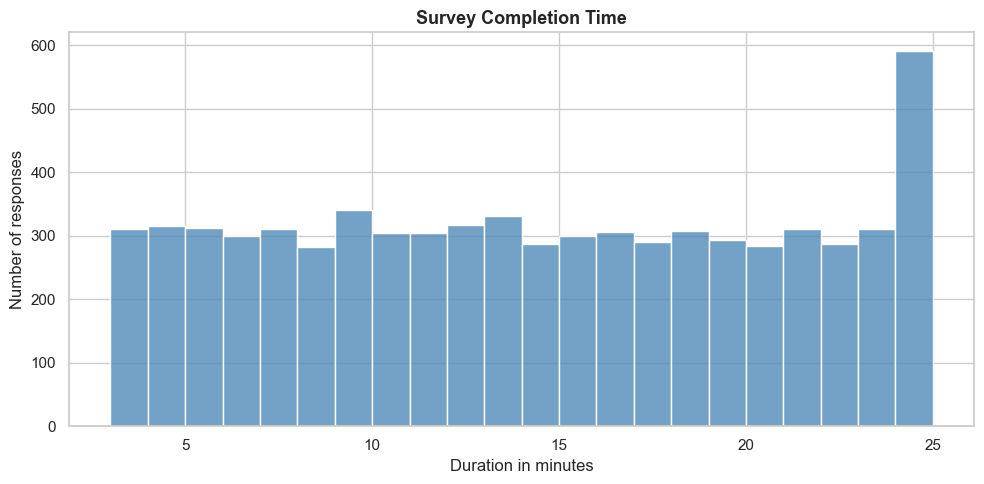

In [40]:
# ============================================================
# Completion Time
# ============================================================

# Display descriptive statistics for completion times.
# Extreme long-duration cases can strongly affect the mean and the plot scale.
display(
    data["duration_minutes"]
    .describe()
    .round(2)
)

# Inspect unusually long completion times separately.
# These cases may indicate interruptions during survey completion rather than
# active response time.
long_duration_threshold = 60

long_duration_cases = data.loc[
    data["duration_minutes"] > long_duration_threshold,
    ["start", "ende", "duration_minutes", "iteration_id", "run_id"]
].sort_values(
    "duration_minutes",
    ascending=False
)

print(
    f"Responses longer than {long_duration_threshold} minutes: "
    f"{len(long_duration_cases):,}"
)

display(
    long_duration_cases.head(10)
)

# ------------------------------------------------------------
# Plot main completion-time distribution
# ------------------------------------------------------------

# The full distribution contains extreme long-duration cases.
# For readability, the histogram is restricted to the range that captures
# plausible active completion times.
plot_data = data.loc[
    data["duration_minutes"].between(0, 30),
    "duration_minutes"
]

plt.figure(figsize=(10, 5))

sns.histplot(
    plot_data,
    binwidth=1,
    color="steelblue"
)

plt.title(
    "Survey Completion Time",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Duration in minutes")
plt.ylabel("Number of responses")

plt.tight_layout()
plt.show()

## 5.2 Speeding

Speeding describes response behaviour characterised by unusually short survey completion times.

Because respondents require a minimum amount of time to read and answer questionnaire items carefully, very short completion times may indicate reduced response quality.

The speeding analysis is exploratory and does not lead to the automatic exclusion of cases. Instead, potentially affected responses are flagged for later inspection.

In [41]:
# ============================================================
# Speeding Detection
# ============================================================

# Define a conservative threshold based on the lower 5% of the
# completion-time distribution.

speeding_threshold = (
    data["duration_minutes"]
    .quantile(0.05)
)

# Flag potentially speeding respondents.
data["flag_speeder"] = (
    data["duration_minutes"]
    <= speeding_threshold
)

print(
    f"Speeding threshold: "
    f"{speeding_threshold:.2f} minutes"
)

print(
    f"Potential speeders: "
    f"{data['flag_speeder'].sum():,}"
)

print(
    f"Percentage: "
    f"{data['flag_speeder'].mean() * 100:.1f}%"
)

Speeding threshold: 4.00 minutes
Potential speeders: 626
Percentage: 8.9%


## 5.3 Straightlining

Straightlining occurs when respondents repeatedly select the same response option across many survey items.

Although consistent answers are not necessarily problematic, extremely low response variation may indicate disengaged or inattentive responding.

To identify potential straightlining behaviour, the within-person standard deviation across survey items is calculated.

As with the speeding analysis, these indicators are used descriptively and do not automatically exclude respondents from the dataset.

Potential straightliners: 0
Percentage: 0.0%


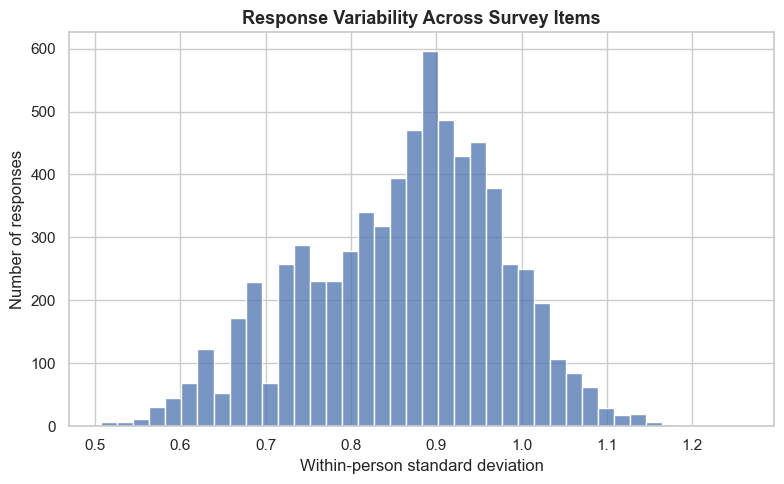

In [42]:
# ============================================================
# Straightlining Detection
# ============================================================

# Calculate within-person response variability across all survey items.
# Lower values indicate less variation in responses.

data["answer_std"] = (
    data[cols_to_recode]
    .std(axis=1)
)

# Flag respondents with zero answer variation.
# These respondents selected the same response option for all available items.

data["flag_straightliner"] = (
    data["answer_std"] == 0
)

print(
    f"Potential straightliners: "
    f"{data['flag_straightliner'].sum():,}"
)

print(
    f"Percentage: "
    f"{data['flag_straightliner'].mean() * 100:.1f}%"
)

# Visualise response variability.
plt.figure(figsize=(8, 5))

sns.histplot(
    data["answer_std"],
    bins=40
)

plt.title(
    "Response Variability Across Survey Items",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Within-person standard deviation")
plt.ylabel("Number of responses")

plt.tight_layout()
plt.show()

## 5.4 Quality Flags

The individual quality indicators are combined into a set of descriptive quality flags.

These flags are intended to identify potentially unusual response patterns, such as:

- unusually short completion times,
- extremely low response variability,
- or combinations of both indicators.

Importantly, flagged responses are not removed from the dataset. The purpose of the quality flags is to provide transparency regarding potential data-quality issues while preserving the original sample for subsequent analyses.

The flags can later be used for sensitivity analyses, robustness checks, or model diagnostics.

,count,share_%
Potential speeders,626,8.94
Potential straightliners,0,0.00
Flagged by both indicators,0,0.00


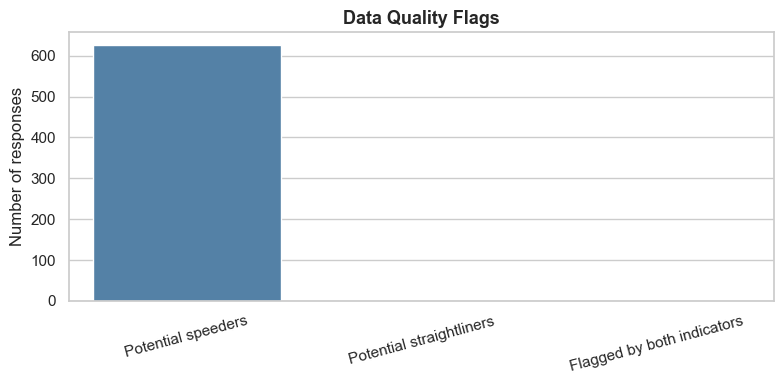

In [43]:
# ============================================================
# Quality Flags
# ============================================================

# Conservative overall quality flag:
# Respondents are flagged only if they meet both criteria:
# - unusually short completion time
# - zero response variation

data["flag_quality"] = (
    data["flag_speeder"]
    & data["flag_straightliner"]
)

# ------------------------------------------------------------
# Quality Summary
# ------------------------------------------------------------

quality_summary = pd.DataFrame({
    "count": [
        data["flag_speeder"].sum(),
        data["flag_straightliner"].sum(),
        data["flag_quality"].sum()
    ],
    "share_%": [
        data["flag_speeder"].mean() * 100,
        data["flag_straightliner"].mean() * 100,
        data["flag_quality"].mean() * 100
    ]
},
index=[
    "Potential speeders",
    "Potential straightliners",
    "Flagged by both indicators"
])

quality_summary["share_%"] = (
    quality_summary["share_%"]
    .round(2)
)

display(quality_summary)

# ------------------------------------------------------------
# Visualise quality flags
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

sns.barplot(
    x=quality_summary.index,
    y=quality_summary["count"],
    color="steelblue"
)

plt.title(
    "Data Quality Flags",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Number of responses")
plt.xlabel("")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 5.5 Quality Overview

The previous analyses examined several indicators of response quality, including completion time, speeding behaviour, and response variability.

Taken together, these indicators provide a descriptive assessment of the overall data quality.

Rather than excluding responses automatically, the identified quality flags are retained as analytical variables. This approach preserves the original sample while allowing potential data-quality issues to be considered in later analyses and modelling workflows.

Overall, the results help to determine whether the dataset is suitable for subsequent psychometric analyses, organisational comparisons, and machine-learning applications.

In [44]:
# ============================================================
# Quality Overview
# ============================================================

# Summarise key quality indicators in a single table.

quality_overview = pd.DataFrame({
    "metric": [
        "Responses",
        "Potential speeders",
        "Potential straightliners",
        "Flagged by both indicators"
    ],
    "count": [
        len(data),
        data["flag_speeder"].sum(),
        data["flag_straightliner"].sum(),
        data["flag_quality"].sum()
    ]
})

quality_overview["share_%"] = (
    quality_overview["count"]
    / len(data)
    * 100
).round(2)

quality_overview.loc[
    quality_overview["metric"] == "Responses",
    "share_%"
] = 100.0

display(quality_overview)

# Cross-tabulation of quality indicators.
quality_crosstab = pd.crosstab(
    data["flag_speeder"],
    data["flag_straightliner"],
    margins=True
)

print("\nOverlap of quality indicators:")
display(quality_crosstab)


,metric,count,share_%
0,Responses,7000,100.00
1,Potential speeders,626,8.94
2,Potential straightliners,0,0.00
3,Flagged by both indicators,0,0.00



Overlap of quality indicators:


flag_straightliner,False,All
flag_speeder,,
False,6374,6374
True,626,626
All,7000,7000


---

# 6. Descriptive Statistics

---

After preparing the survey scores and assessing data quality, the dataset is explored descriptively.

The purpose of this section is to obtain an overview of response patterns across individual survey items and broader thematic dimensions.

The analyses focus on:

- descriptive statistics of individual survey items,
- distributions of the derived topic scores,
- and the internal consistency of the predefined topic groups.

Together, these analyses provide a first substantive understanding of the survey results and help evaluate the psychometric quality of the High5 framework before moving on to organisational and free-text analyses.

## 6.1 Item Statistics

The distribution of individual survey items is examined to obtain a first impression of response tendencies across the questionnaire.

For each item, descriptive statistics are calculated, including:

- number of valid responses,
- mean,
- standard deviation,
- minimum,
- maximum.

These statistics help identify items with unusually high or low ratings, limited response variability, and potential ceiling or floor effects.

In [45]:
# ============================================================
# Item Statistics
# ============================================================

item_statistics = (
    data[cols_to_recode]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "max"
    ])
    .T
    .round(2)
    .sort_values("mean")
)

display(item_statistics)

,count,mean,std,min,max
ueberlastung,7000.0,2.89,1.16,1.0,5.0
teamstimmung,7000.0,3.14,1.13,1.0,5.0
feedback_nutzen,7000.0,3.22,1.28,1.0,5.0
veraenderung_nachvollziehbar,7000.0,3.24,1.28,1.0,5.0
neues_lernen,7000.0,3.24,1.27,1.0,5.0
eigenverantwortung_entscheidungen,7000.0,3.24,1.27,1.0,5.0
prozessverbesserung_kontinuierlich,7000.0,3.24,1.28,1.0,5.0
businessentscheidungen_richtung,7000.0,3.24,1.27,1.0,5.0
kulturentwicklung_richtung,7000.0,3.24,1.28,1.0,5.0
info_fuehrung_veraenderung,7000.0,3.24,1.27,1.0,5.0


## 6.2 Topic Score Distributions

Topic scores provide a more compact representation of the questionnaire by combining related survey items into broader thematic dimensions.

The distribution of topic scores is inspected to evaluate:

- central tendencies,
- variability between respondents,
- potential ceiling effects,
- and overall response patterns across dimensions.

Higher values indicate more positive evaluations.

,team_score,kultur_score,fuehrung_score,strategie_score,arbeitsgestaltung_score,entwicklung_score,wertschoepfung_score,engagement_score
count,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00
mean,3.23,3.25,3.25,3.26,3.25,3.25,3.25,3.22
std,1.00,1.00,1.01,1.01,1.00,1.01,1.00,1.01
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,2.50,2.57,2.67,2.67,2.62,2.57,2.67,2.60
50%,3.33,3.29,3.33,3.33,3.25,3.29,3.22,3.20
75%,4.00,4.14,4.00,4.00,4.00,4.14,4.11,4.20
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


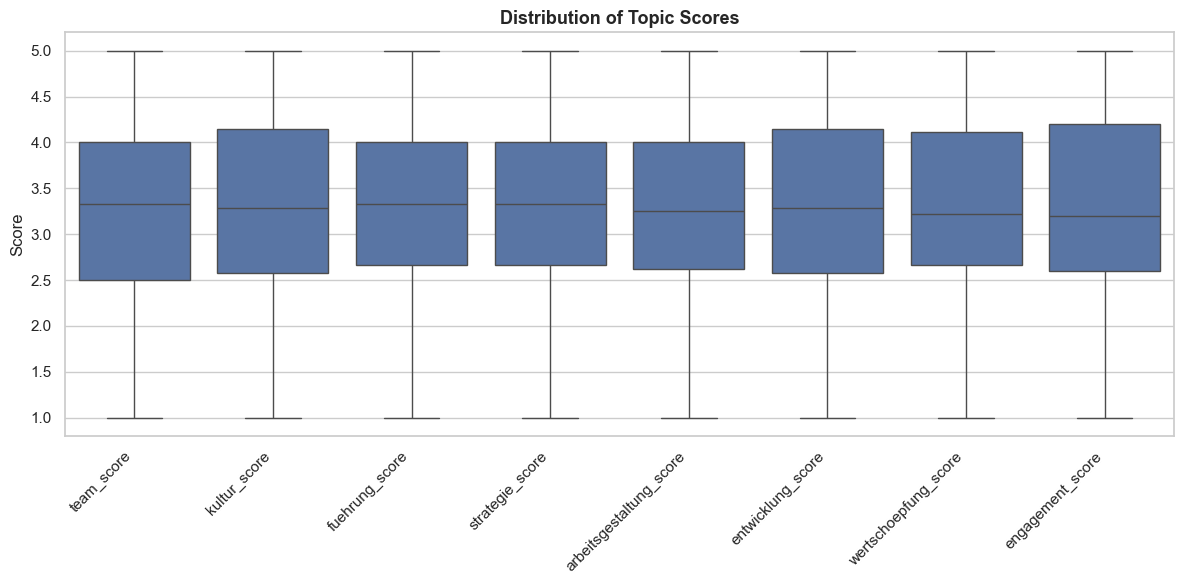

In [46]:
# ============================================================
# Topic Score Distributions
# ============================================================

display(
    data[score_cols]
    .describe()
    .round(2)
)

# Visualise score distributions.
plot_data = (
    data[score_cols]
    .melt(
        var_name="topic",
        value_name="score"
    )
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_data,
    x="topic",
    y="score"
)

plt.title(
    "Distribution of Topic Scores",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 6.3 Reliability Analysis

Internal consistency is assessed for each topic group using Cronbach's Alpha.

Cronbach's Alpha measures the extent to which items within a topic group assess the same underlying construct.

The interpretation used throughout this analysis is:

| Cronbach's Alpha | Interpretation |
|------------------|----------------|
| < 0.60 | Poor |
| 0.60 – 0.69 | Questionable |
| 0.70 – 0.79 | Acceptable |
| 0.80 – 0.89 | Good |
| ≥ 0.90 | Excellent |

Reliability estimates are reported descriptively and help evaluate the psychometric quality of the predefined topic groups.

In [47]:
# ============================================================
# Reliability Analysis
# ============================================================

def cronbach_alpha(df):

    df = df.dropna(how="all")

    k = df.shape[1]

    if k < 2:
        return np.nan

    item_variances = df.var(axis=0, ddof=1)

    total_score = df.sum(axis=1)

    total_variance = total_score.var(ddof=1)

    if total_variance == 0:
        return np.nan

    return (
        k / (k - 1)
    ) * (
        1 - item_variances.sum() / total_variance
    )


reliability_results = []

for topic, items in categories_dict.items():

    alpha = cronbach_alpha(
        data[items]
    )

    reliability_results.append({
        "topic": topic,
        "cronbach_alpha": alpha
    })

reliability = (
    pd.DataFrame(reliability_results)
    .sort_values(
        "cronbach_alpha",
        ascending=False
    )
)

display(
    reliability.round(3)
)


,topic,cronbach_alpha
6,"Customer, Product & Process Focus",0.922
4,Work Structure & Responsibility,0.911
5,Development & Learning,0.902
1,Psychological Safety & Culture,0.900
7,Engagement & Wellbeing,0.891
0,Teamwork & Collaboration,0.886
2,Leadership & Communication,0.885
3,Strategy & Business,0.884


## 6.4 Missingness of Topic Scores

Although topic scores are calculated from multiple survey items, some scores may still be missing when respondents did not provide sufficient information.

This section examines the completeness of the derived topic scores and evaluates the impact of missing data on the analytical dataset.

The analysis helps determine:

- which topic scores are most frequently missing,
- whether missingness is concentrated in specific dimensions,
- and whether the resulting scores are suitable for subsequent analyses and machine-learning applications.

,missing_values,share_%
team_score,0,0.0
kultur_score,0,0.0
fuehrung_score,0,0.0
strategie_score,0,0.0
arbeitsgestaltung_score,0,0.0
entwicklung_score,0,0.0
wertschoepfung_score,0,0.0
engagement_score,0,0.0


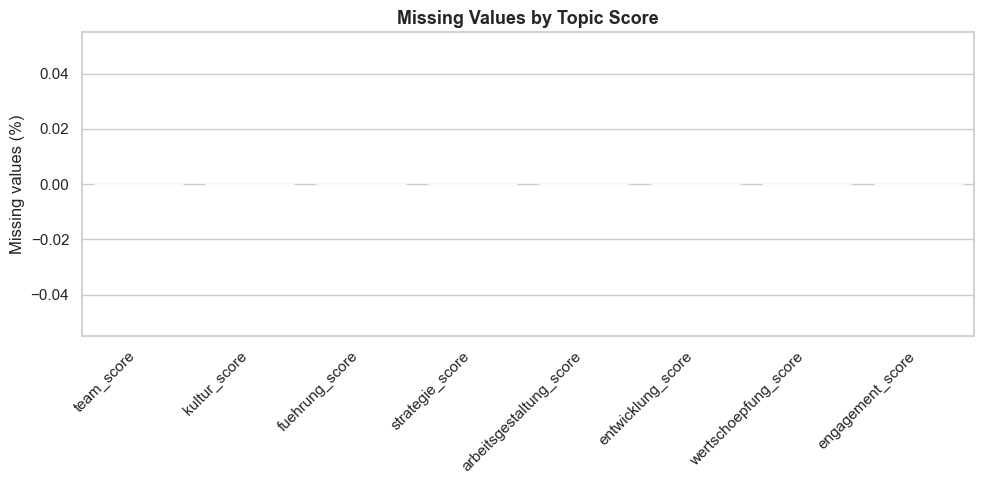

In [48]:
# ============================================================
# Missingness of Topic Scores
# ============================================================

# Summarise missing values across all derived topic scores.

score_missingness = pd.DataFrame({
    "missing_values": data[score_cols].isna().sum(),
    "share_%": (
        data[score_cols].isna().mean() * 100
    ).round(2)
}).sort_values(
    "share_%",
    ascending=False
)

display(score_missingness)

# ------------------------------------------------------------
# Visualise topic-score completeness
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.barplot(
    data=score_missingness.reset_index(),
    x="index",
    y="share_%",
    color="steelblue"
)

plt.title(
    "Missing Values by Topic Score",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Missing values (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

---

# 7. Organisational Analysis

---

The High5 survey is designed to support organisational learning and improvement. Therefore, it is important to examine how responses vary across business units.

To improve comparability and reduce sparsity, analyses are conducted at the business-unit level (`bereich_ebene`) rather than at the original organisational level.

The analyses in this section focus on:

- the distribution of responses across business units,
- differences in topic scores between organisational units,
- and patterns in free-text commenting behaviour.

The results provide a first indication of how employee perceptions vary across different parts of the organisation.

## 7.1 Business Unit Structure

Before comparing survey results across business units, it is useful to understand the organisational composition of the dataset.

This analysis examines the number of responses contributed by each business unit and highlights differences in sample size across the organisation.

Understanding these distributions is important because very small groups can lead to unstable estimates and should be interpreted with caution.

,business_unit,n
0,ZU-BE,1426
1,FO-GA,1412
2,KE-EP,1402
3,TR-DE,1380
4,IN-AL,1380


count       5.00
mean     1400.00
std        20.15
min      1380.00
25%      1380.00
50%      1402.00
75%      1412.00
max      1426.00
Name: n, dtype: float64

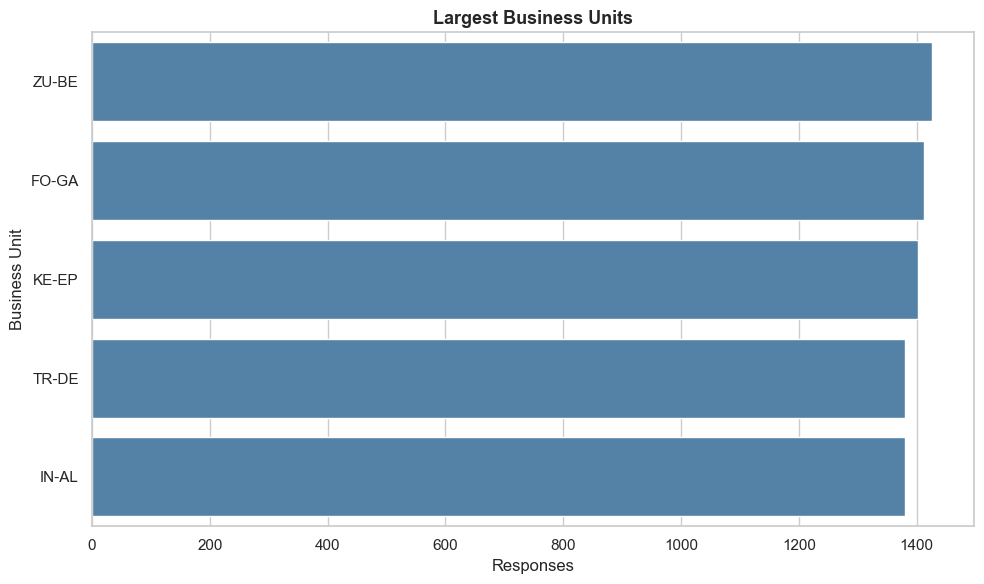

In [49]:
# ============================================================
# Business Unit Structure
# ============================================================

bereich_sizes = (
    data["bereich_ebene"]
    .value_counts()
    .rename_axis("business_unit")
    .reset_index(name="n")
)

display(bereich_sizes.head(20))

display(
    bereich_sizes["n"]
    .describe()
    .round(2)
)

# Visualise largest business units.
plt.figure(figsize=(10, 6))

sns.barplot(
    data=bereich_sizes.head(20),
    y="business_unit",
    x="n",
    color="steelblue"
)

plt.title(
    "Largest Business Units",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Responses")
plt.ylabel("Business Unit")

plt.tight_layout()
plt.show()

## 7.2 Topic Scores by Business Unit

Average topic scores are compared across business units to identify potential differences in employee perceptions.

To ensure meaningful comparisons, only business units with a minimum number of responses are included.

The analysis is descriptive and focuses on broad patterns rather than formal statistical testing.

,team_score,kultur_score,fuehrung_score,strategie_score,arbeitsgestaltung_score,entwicklung_score,wertschoepfung_score,engagement_score
bereich_ebene,,,,,,,,
FO-GA,3.18,3.20,3.20,3.22,3.20,3.19,3.20,3.16
IN-AL,3.25,3.27,3.28,3.27,3.27,3.27,3.26,3.24
KE-EP,3.29,3.31,3.31,3.31,3.30,3.30,3.30,3.28
TR-DE,3.23,3.23,3.24,3.23,3.24,3.25,3.23,3.21
ZU-BE,3.23,3.26,3.24,3.25,3.25,3.23,3.25,3.24


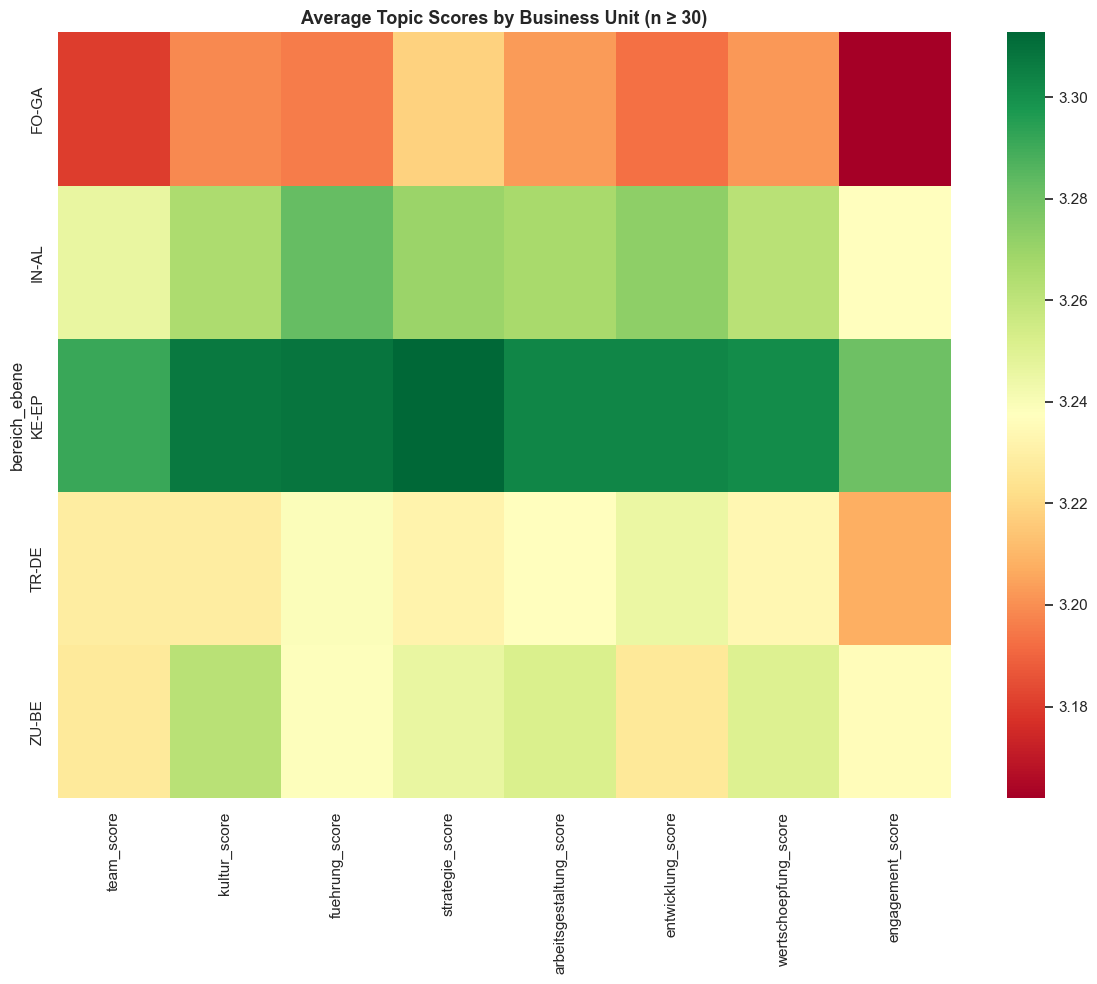

In [50]:
# ============================================================
# Topic Scores by Business Unit
# ============================================================

MIN_RESPONSES = 30

eligible_units = (
    data["bereich_ebene"]
    .value_counts()
    .loc[lambda s: s >= MIN_RESPONSES]
    .index
)

business_unit_scores = (
    data.loc[
        data["bereich_ebene"].isin(eligible_units)
    ]
    .groupby("bereich_ebene")[score_cols]
    .mean()
)

display(
    business_unit_scores.round(2)
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    business_unit_scores,
    cmap="RdYlGn",
    annot=False
)

plt.title(
    f"Average Topic Scores by Business Unit (n ≥ {MIN_RESPONSES})",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 7.3 Comment Rates by Business Unit

Providing a free-text comment requires additional effort and may reflect a stronger desire to express opinions, concerns, or suggestions.

This analysis examines the proportion of respondents who provided a comment within each business unit.

To avoid unstable estimates, only business units with sufficient numbers of responses are considered.

,with_comment,n,share_%
bereich_ebene,,,
IN-AL,998,1380,72.3
KE-EP,1008,1402,71.9
ZU-BE,1024,1426,71.8
FO-GA,1008,1412,71.4
TR-DE,962,1380,69.7


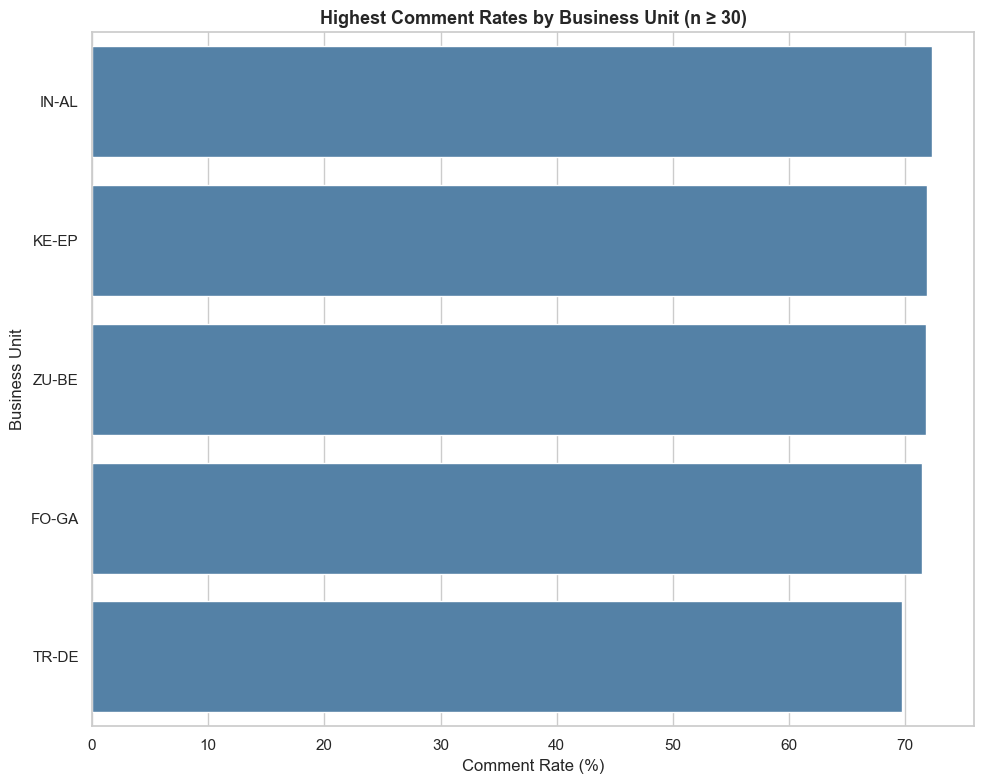

In [51]:
# ============================================================
# Comment Rates by Business Unit
# ============================================================

MIN_RESPONSES = 30

comment_rate = (
    data
    .dropna(subset=["bereich_ebene"])
    .groupby("bereich_ebene")["has_comment"]
    .agg(
        with_comment="sum",
        n="count",
        share="mean"
    )
)

comment_rate["share_%"] = (
    comment_rate["share"] * 100
).round(1)

comment_rate = (
    comment_rate
    .drop(columns="share")
    .query("n >= @MIN_RESPONSES")
    .sort_values("share_%", ascending=False)
)

display(comment_rate)

# Visualise comment rates.
plt.figure(figsize=(10, 8))

sns.barplot(
    data=comment_rate.head(20).reset_index(),
    y="bereich_ebene",
    x="share_%",
    color="steelblue"
)

plt.title(
    f"Highest Comment Rates by Business Unit (n ≥ {MIN_RESPONSES})",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Comment Rate (%)")
plt.ylabel("Business Unit")

plt.tight_layout()
plt.show()

---

# 8. Correlation Analysis

---

Relationships between the derived topic scores are examined to better understand how the different dimensions of the High5 framework relate to one another.

Correlations provide insight into:

- conceptual overlap between dimensions,
- potential dependencies between constructs,
- and the overall structure of the survey framework.

Because topic scores represent aggregated constructs, correlations are examined at the score level rather than at the individual item level.

## 8.1 Topic Score Correlations

Pearson correlations are calculated between all topic scores.

Strong positive correlations indicate that respondents who evaluate one dimension positively also tend to evaluate another dimension positively.

The resulting correlation matrix provides a compact overview of the relationships between the key constructs of the High5 framework.

,team_score,kultur_score,fuehrung_score,strategie_score,arbeitsgestaltung_score,entwicklung_score,wertschoepfung_score,engagement_score
team_score,1.00,0.90,0.89,0.89,0.90,0.90,0.90,0.89
kultur_score,0.90,1.00,0.89,0.89,0.91,0.90,0.91,0.90
fuehrung_score,0.89,0.89,1.00,0.89,0.90,0.89,0.90,0.89
strategie_score,0.89,0.89,0.89,1.00,0.90,0.90,0.90,0.89
arbeitsgestaltung_score,0.90,0.91,0.90,0.90,1.00,0.91,0.92,0.90
entwicklung_score,0.90,0.90,0.89,0.90,0.91,1.00,0.91,0.89
wertschoepfung_score,0.90,0.91,0.90,0.90,0.92,0.91,1.00,0.90
engagement_score,0.89,0.90,0.89,0.89,0.90,0.89,0.90,1.00


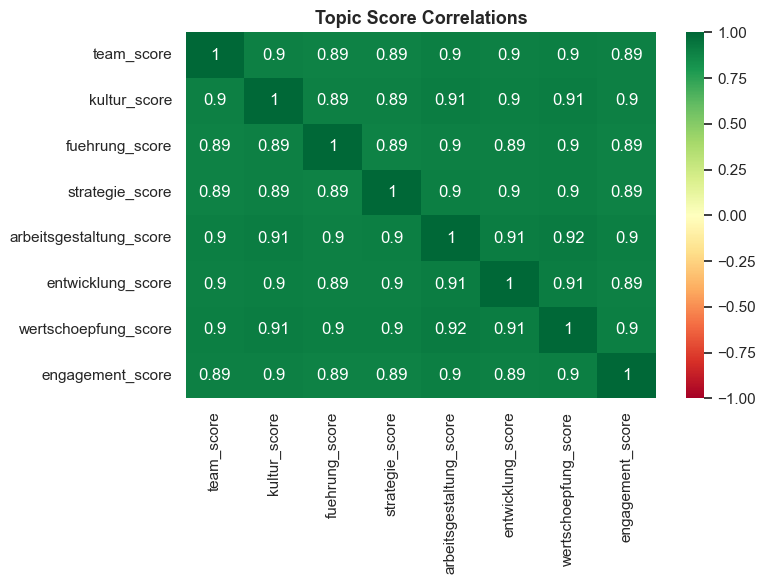

In [52]:
# ============================================================
# Topic Score Correlations
# ============================================================

score_correlations = (
    data[score_cols]
    .corr()
)

display(
    score_correlations.round(2)
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    score_correlations,
    annot=True,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.title(
    "Topic Score Correlations",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

---

# 9. Free-Text Exploration

---

In addition to structured survey items, respondents were invited to provide optional free-text comments.

These comments offer valuable qualitative insights that complement the quantitative survey results.

This section focuses on:

- participation in free-text commenting,
- differences between commenters and non-commenters,
- comment length,
- and an initial review of the comment content.

The detailed text analyses are conducted in later notebooks.


## 9.1 Comment Distribution

The first step is to determine how many respondents provided a free-text comment.

This provides an indication of overall participation in the qualitative component of the survey.

has_comment
With Comment       5000
Without Comment    2000
Name: count, dtype: int64

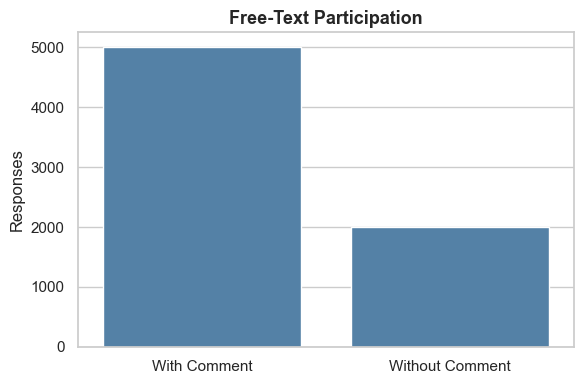

In [53]:
# ============================================================
# Comment Distribution
# ============================================================

comment_distribution = (
    data["has_comment"]
    .value_counts()
    .rename(index={
        False: "Without Comment",
        True: "With Comment"
    })
)

display(comment_distribution)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=comment_distribution.index,
    y=comment_distribution.values,
    color="steelblue"
)

plt.title(
    "Free-Text Participation",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel("Responses")
plt.xlabel("")

plt.tight_layout()
plt.show()

## 9.2 Commenters vs Non-Commenters

Respondents who choose to provide a free-text comment may differ systematically from those who do not.

To assess potential selection effects, average topic scores are compared between respondents who submitted a comment and respondents who did not.

This comparison helps evaluate whether free-text comments represent the broader respondent population or a more specific subgroup.

Differences in topic scores may indicate that commenters tend to hold systematically more positive or more critical views than non-commenters, which should be considered when interpreting later text-analysis results.

has_comment,without_comment,with_comment,difference
arbeitsgestaltung_score,3.25,3.25,0.01
wertschoepfung_score,3.24,3.25,0.01
fuehrung_score,3.24,3.26,0.02
strategie_score,3.24,3.26,0.02
entwicklung_score,3.23,3.25,0.02
team_score,3.22,3.24,0.03
kultur_score,3.23,3.26,0.03
engagement_score,3.20,3.23,0.03


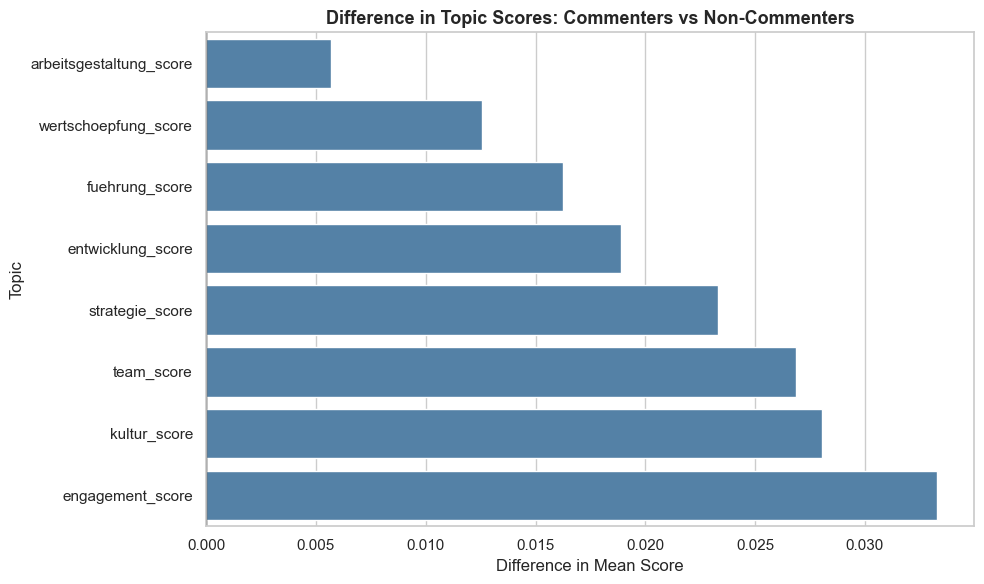


Group sizes:


has_comment
with_comment       5000
without_comment    2000
Name: count, dtype: int64

In [54]:
# ============================================================
# Commenters vs Non-Commenters
# ============================================================

# Compare average topic scores between respondents who provided
# a free-text comment and those who did not.

comparison = (
    data
    .groupby("has_comment")[score_cols]
    .mean()
    .T
)

comparison = comparison.rename(
    columns={
        False: "without_comment",
        True: "with_comment"
    }
)

# Calculate score differences.
# Negative values indicate that commenters rated the topic lower.
comparison["difference"] = (
    comparison["with_comment"]
    - comparison["without_comment"]
)

# Display results.
display(
    comparison
    .round(2)
    .sort_values("difference")
)

# ------------------------------------------------------------
# Visualise differences
# ------------------------------------------------------------

comparison_plot = (
    comparison
    .sort_values("difference")
    .reset_index()
    .rename(columns={"index": "topic"})
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_plot,
    y="topic",
    x="difference",
    color="steelblue"
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Difference in Topic Scores: Commenters vs Non-Commenters",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Difference in Mean Score")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Group sizes
# ------------------------------------------------------------

comment_group_sizes = (
    data["has_comment"]
    .value_counts()
    .rename(index={
        False: "without_comment",
        True: "with_comment"
    })
)

print("\nGroup sizes:")
display(comment_group_sizes)

## 9.3 Comment Length

Comment length provides a simple indicator of respondent engagement in the qualitative section of the survey.

The distribution of comment lengths is explored descriptively using word counts.

count    5000.000000
mean       70.462800
std        10.417558
min        37.000000
25%        67.000000
50%        71.000000
75%        77.000000
max       103.000000
Name: comment_word_count, dtype: float64

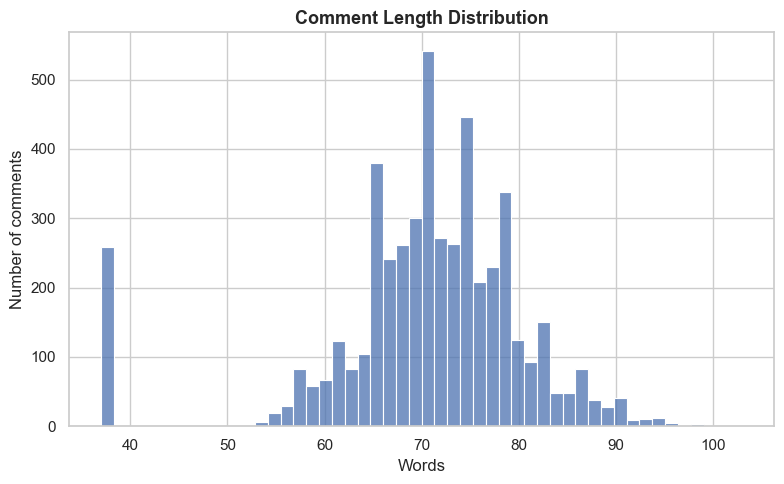

In [55]:
# ============================================================
# Comment Length
# ============================================================

comments = data.loc[
    data["has_comment"]
].copy()

comments["comment_word_count"] = (
    comments["freitext_kommentar"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    comments["comment_word_count"]
    .describe()
)

plt.figure(figsize=(8, 5))

sns.histplot(
    comments["comment_word_count"],
    bins=50
)

plt.title(
    "Comment Length Distribution",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Words")
plt.ylabel("Number of comments")

plt.tight_layout()
plt.show()

## 9.4 Comment Preview

A small random sample of comments is displayed to obtain an initial impression of the qualitative content.

These examples are shown for exploratory purposes only and do not represent a formal qualitative analysis.

In [56]:
# ============================================================
# Comment Preview
# ============================================================

display(
    comments["freitext_kommentar"]
    .dropna()
    .sample(
        min(10, len(comments)),
        random_state=42
    )
)

2068    Im Kontext 'Strategischer Austausch' werden in...
3605    Im Kontext 'Tägliches operatives Geschäft' wer...
3709    Im Kontext 'Konzeptionelles Arbeiten' werden i...
1464    Im Kontext 'Konzeptionelles Arbeiten' werden i...
985     Im Kontext 'Planung und Ausrichtung' werden in...
157     Im Kontext 'Planung und Ausrichtung' werden in...
830     Im Kontext 'Kollaborativer Arbeitsmodus' werde...
3449    In the context of kein spezifischer fokus, emp...
3374    Im Kontext 'Konzeptionelles Arbeiten' werden i...
2219    Im Kontext 'Konzeptionelles Arbeiten' werden i...
Name: freitext_kommentar, dtype: object

---

# 10. Summary

---

Key findings from the exploratory analysis are documented separately in `findings.md`.

The results of this notebook provide the basis for:

- comparison with the synthetic dataset,
- construction of modelling datasets,
- and subsequent machine-learning analyses of the free-text comments.

In [57]:
from pathlib import Path

# ============================================================
# Save Cleaned Dataset
# ============================================================

OUTPUT_PATH = Path(
    "../data/processed/synthetic_eda_ready.csv"
)

data.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Saved: {OUTPUT_PATH}"
)

Saved: ../data/processed/synthetic_eda_ready.csv
